In [134]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
from torch.autograd import Variable   # variable from numpy to torch
import matplotlib.pyplot as plt       # import pyplot library

In [135]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [136]:
epochs = 300  # number of training epochs
col_p  = 200  # number of collocation points
hid_n  = 75   # number of neurons on hidden layers

class NN(nn.Module):                           # create neural network
    def __init__(self):                        # initialize 
        super(NN, self).__init__()             # input layer, 1 input - x
        self.hidden_lay1 = nn.Linear(1,hid_n)    # first hidden layer, 150 neurons
        self.hidden_lay2 = nn.Linear(hid_n,hid_n)  # seconfd hidden layer, 150 neurons
        self.output_lay  = nn.Linear(hid_n,1)    # output layer, 1 output - u(x)
        
    def forward(self,x):
        inputs   = x                     
        lay1_out = torch.tanh(self.hidden_lay1(inputs))   # sigmoid activation function in hidden layer
        lay2_out = torch.tanh(self.hidden_lay2(lay1_out)) # sigmoid activation function in hidden layer
        output   = self.output_lay(lay2_out)                 # for regression, no activation is used in output layer
        return output

In [137]:
### (2) Model
NN = NN()
NN = NN.to(device)                               # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()           # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters(), lr=0.002)    # Adam optimizer for parameter updating

In [138]:
## PDE as loss function.
def f(x,NN):
    u = NN(x) # the dependent variable u is given by the network based on independent variable x
    ## Based on our f = d4u/dx4 - sin(x) - sin^2(x) + (d2u/du2)^2, we need d4u/dx4 and d2u/du2
    u_x  = torch.autograd.grad(u.sum(), x, create_graph=True)[0]   # du/dx
    u_x2 = torch.autograd.grad(u_x.sum(),x,create_graph=True)[0]   # d2u/dx2
    u_x3 = torch.autograd.grad(u_x2.sum(),x,create_graph=True)[0]  # d3u/dx3
    u_x4 = torch.autograd.grad(u_x3.sum(),x,create_graph=True)[0]  # d4u/dx4
    pde = u_x4 - torch.sin(x) - torch.sin(x) + u_x2**2                        
    return pde

In [139]:
## Data from Boundary Conditions
## BC gives us datapoints for training
## We will find out u(x) for x in range [0,1]

#################################### 1. x=0, u(0)=0 ####################################
x_bc1 = np.zeros((col_p,1))          # Take say 200 random numbers of (x,u)
u_bc1 = np.zeros((col_p,1))          # Compute u based on BC

#################################### 2. x=0, du/dx=1 ###################################
x_bc2   = np.zeros((col_p,1))        # Take say 200 random numbers of (x,y)
u_x_bc2 = np.ones((col_p,1))         # Compute du/dx based on BC

#################################### 3. x=1, u(1)=sin(1) ###############################
x_bc3 = np.ones((col_p,1))           # Take say 200 random numbers of (x,y)
u_bc3 = np.sin(np.ones((col_p,1)))   # Compute u based on BC

#################################### 4. x=1, du/dx=cos(1) ##############################
x_bc4   = np.ones((col_p,1))         # Take say 200 random numbers of (x,y)
u_x_bc4 = np.cos(np.ones((col_p,1))) # Compute du/dx based on BC

In [140]:
### (3) Training / Fitting
L = []                    # Creating empty list for gathering loss values

previous_validation_loss = np.Inf
for epoch in range(epochs):
    optimizer.zero_grad() # to make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.
    pt_x_bc1   = Variable(torch.from_numpy(x_bc1).float(), requires_grad=False).to(device)
    pt_u_bc1   = Variable(torch.from_numpy(u_bc1).float(), requires_grad=False).to(device)
    
    NN_bc1_out = NN(pt_x_bc1) # output NN(x) --> u
    mse_u1     = mse_cost_function(NN_bc1_out, pt_u_bc1)
    
    # BC 2.
    pt_x_bc2   = Variable(torch.from_numpy(x_bc2).float(), requires_grad=True).to(device)
    pt_u_x_bc2 = Variable(torch.from_numpy(u_x_bc2).float(), requires_grad=False).to(device)
    
    NN_bc2_out = NN(pt_x_bc2) # output NN(x) --> u
    du_x_bc2   = torch.autograd.grad(NN_bc2_out.sum(),pt_x_bc2,create_graph=True)[0]
    mse_u2     = mse_cost_function(du_x_bc2, pt_u_x_bc2)
    
    # BC 3.
    pt_x_bc3   = Variable(torch.from_numpy(x_bc3).float(), requires_grad=False).to(device)
    pt_u_bc3   = Variable(torch.from_numpy(u_bc3).float(), requires_grad=False).to(device)
    
    NN_bc3_out = NN(pt_x_bc3) # output NN(x) --> u
    mse_u3     = mse_cost_function(NN_bc3_out, pt_u_bc3)
        
    # BC 4.
    pt_x_bc4   = Variable(torch.from_numpy(x_bc4).float(), requires_grad=True).to(device)
    pt_u_x_bc4 = Variable(torch.from_numpy(u_x_bc4).float(), requires_grad=False).to(device)
    
    NN_bc4_out = NN(pt_x_bc4) # output NN(x) --> u
    du_x_bc4   = torch.autograd.grad(NN_bc4_out.sum(),pt_x_bc4,create_graph=True)[0]
    mse_u4     = mse_cost_function(du_x_bc4, pt_u_x_bc4)
    
    # Loss based on PDE
    x_col      = np.random.uniform(low=0.0, high=1.0, size=(col_p,1))
    all_zeros  = np.zeros((col_p,1))
    pt_x_col     = Variable(torch.from_numpy(x_col).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out        = f(pt_x_col,NN)                # output of f(x,t)
    mse_f        = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u1 + mse_u2 + mse_u3 + mse_u4 + mse_f
    
    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to: theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_np = loss.data.cpu().numpy() # Torch tensors to Numpy
    L = np.append(L,loss_np)          # Tracking loss values and creating a list
    
    with torch.autograd.no_grad():
        if epoch % 10 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

0 Traning Loss: tensor(3.6084, device='cuda:0')
10 Traning Loss: tensor(0.3265, device='cuda:0')
20 Traning Loss: tensor(0.0973, device='cuda:0')
30 Traning Loss: tensor(0.0616, device='cuda:0')
40 Traning Loss: tensor(0.0264, device='cuda:0')
50 Traning Loss: tensor(0.0126, device='cuda:0')
60 Traning Loss: tensor(0.0107, device='cuda:0')
70 Traning Loss: tensor(0.0087, device='cuda:0')
80 Traning Loss: tensor(0.0073, device='cuda:0')
90 Traning Loss: tensor(0.0066, device='cuda:0')
100 Traning Loss: tensor(0.0057, device='cuda:0')
110 Traning Loss: tensor(0.0044, device='cuda:0')
120 Traning Loss: tensor(0.0038, device='cuda:0')
130 Traning Loss: tensor(0.0031, device='cuda:0')
140 Traning Loss: tensor(0.0026, device='cuda:0')
150 Traning Loss: tensor(0.0021, device='cuda:0')
160 Traning Loss: tensor(0.0017, device='cuda:0')
170 Traning Loss: tensor(0.0014, device='cuda:0')
180 Traning Loss: tensor(0.0012, device='cuda:0')
190 Traning Loss: tensor(0.0010, device='cuda:0')
200 Traning

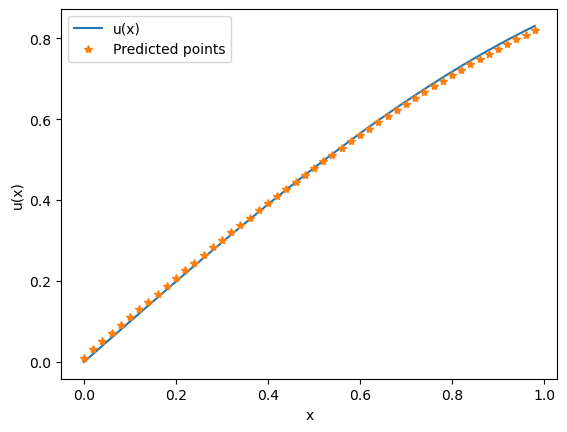

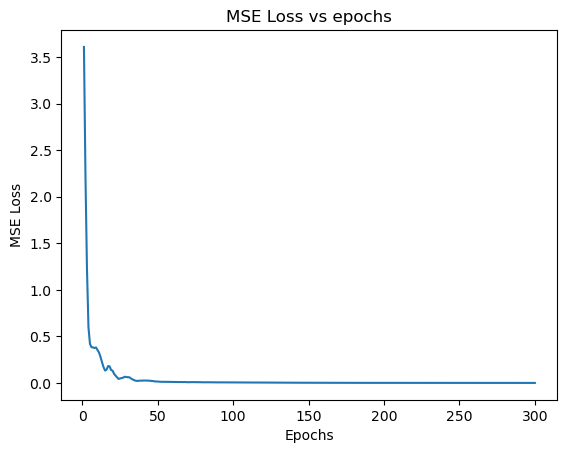

In [141]:
#### Plotting results ###

# Differential equation vs Predicted results
x = np.arange(0,1,0.02)
y = np.sin(x)
x = x.reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_U = NN(pt_x)
U    = pt_U.data.cpu().numpy()

plt.plot(x,y)
plt.plot(x,U,'*')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend(['u(x)','Predicted points'])
plt.show()

#Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.plot(ep,L)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()